# LnT Camp 2026 — Final Project
**Bridging the Gap: Empowering Future Talent through Machine Learning for Industry Innovation**

Tim: 1. Raymond Delbert Harapan
     2. Ivriel Dei Gratia Gunawan
     3. Raffy Reshaina Pasha

## 1. Problem Statement & Objectives
Dataset: Global Superstore (SQLite, ternormalisasi). Perusahaan retail global ingin memahami **pesanan mana yang merugikan** dan **seperti apa segmen customer-nya** agar bisa mengatur diskon dan strategi layanan.

**Task yang dipilih (2 dari 3):**
1. **Classification** — memprediksi apakah sebuah order item *profitable* (`profit > 0`) atau tidak.
2. **Clustering** — segmentasi customer berdasarkan perilaku belanja (total sales, jumlah order, rata-rata diskon, profit margin).

**Tujuan:** (a) mengidentifikasi faktor pemicu kerugian, (b) membangun model yang bisa dipakai tim bisnis lewat API dan aplikasi web, (c) memberi rekomendasi bisnis yang bisa ditindaklanjuti.

In [ ]:
import sqlite3, warnings
import numpy as np, pandas as pd
import matplotlib.pyplot as plt, seaborn as sns
import joblib, json
from pathlib import Path
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler, PowerTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score, roc_auc_score,
                             classification_report, confusion_matrix, ConfusionMatrixDisplay, RocCurveDisplay,
                             silhouette_score)
warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")
DB_PATH = "superstore.db"
DRIVE_ID = "1M2sonY7serOCzWYDCKEdxZ5fJ7quOoKd"
if not Path(DB_PATH).exists():
    import subprocess, sys
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "gdown"], check=True)
    import gdown
    gdown.download(id=DRIVE_ID, output=DB_PATH, quiet=False)


[notice] A new release of pip is available: 26.0.1 -> 26.2.1
[notice] To update, run: pip install --upgrade pip
Downloading...
From: https://drive.google.com/uc?id=1M2sonY7serOCzWYDCKEdxZ5fJ7quOoKd
To: /Users/raffyreshainapasha/Downloads/files/lnt-final-project/notebook/superstore.db
100%|██████████| 10.9M/10.9M [00:04<00:00, 2.20MB/s]


**Penjelasan:** sel ini mengimpor library lalu mengunduh database SQLite dari Google Drive secara otomatis jika belum ada (tanpa download manual, bisa dijalankan di Colab). Pastikan file `superstore.db` muncul di folder kerja.

## 2. Database Connection & Data Loading

In [2]:
con = sqlite3.connect(DB_PATH)
tables = pd.read_sql("SELECT name FROM sqlite_master WHERE type='table'", con)["name"].tolist()
print(tables)
for t in tables:
    print(f"\n== {t} ==")
    print(pd.read_sql(f"PRAGMA table_info({t})", con)[["name", "type"]].to_string(index=False))

['dim_customers', 'dim_products', 'dim_product_name_variants', 'dim_locations', 'orders', 'order_items']

== dim_customers ==
         name type
  customer_id TEXT
customer_name TEXT
      segment TEXT

== dim_products ==
        name type
  product_id TEXT
    category TEXT
sub_category TEXT
product_name TEXT

== dim_product_name_variants ==
            name type
      product_id TEXT
raw_product_name TEXT

== dim_locations ==
       name    type
location_id INTEGER
       city    TEXT
      state    TEXT
    country    TEXT
     region    TEXT
     market    TEXT
    market2    TEXT

== orders ==
          name    type
     order_key    TEXT
  order_id_raw    TEXT
   customer_id    TEXT
    order_date    TEXT
     ship_date    TEXT
     ship_mode    TEXT
order_priority    TEXT
   location_id INTEGER

== order_items ==
         name    type
       row_id INTEGER
    order_key    TEXT
   product_id    TEXT
     discount    REAL
     quantity INTEGER
        sales    REAL
       profit 

**Penjelasan:** kita membuka koneksi `sqlite3` dan mencetak semua tabel beserta kolomnya agar nama kolom pada query JOIN berikutnya terverifikasi.

**Interpretasi:** *(isi: sebutkan jumlah tabel dan hubungan antar tabel, mis. `orders` -> `dim_customers` & `dim_locations`; `order_items` -> `orders` & `dim_products`. Jika ada nama kolom yang berbeda dari query di bawah, sesuaikan dulu.)*

In [3]:
QUERY = """
SELECT oi.row_id, oi.order_key, oi.sales, oi.quantity, oi.discount, oi.profit, oi.shipping_cost,
       o.customer_id, o.order_date, o.ship_date, o.order_priority, o.ship_mode,
       c.segment, p.category, p.sub_category, l.region, l.market, l.country
FROM order_items oi
JOIN orders o        ON oi.order_key  = o.order_key
JOIN dim_customers c ON o.customer_id = c.customer_id
JOIN dim_products p  ON oi.product_id = p.product_id
JOIN dim_locations l ON o.location_id = l.location_id
"""
df = pd.read_sql(QUERY, con)
print(df.shape)
df.head()

(51290, 18)


,row_id,order_key,sales,quantity,discount,profit,shipping_cost,customer_id,order_date,ship_date,order_priority,ship_mode,segment,category,sub_category,region,market,country
0,1,MX-2014-143658_SC-205753,13.0,3,0.0,4.56,1.033,SC-205753,2014-10-02 00:00:00,2014-10-06 00:00:00,Medium,Standard Class,Consumer,Office Supplies,Labels,North,LATAM,Mexico
1,2,MX-2012-155047_KW-165703,252.0,8,0.0,90.72,13.449,KW-165703,2012-10-15 00:00:00,2012-10-20 00:00:00,Medium,Standard Class,Consumer,Furniture,Furnishings,South,LATAM,Colombia
2,3,MX-2012-155047_KW-165703,193.0,2,0.0,54.08,9.627,KW-165703,2012-10-15 00:00:00,2012-10-20 00:00:00,Medium,Standard Class,Consumer,Furniture,Bookcases,South,LATAM,Colombia
3,4,MX-2012-155047_KW-165703,35.0,4,0.0,4.96,1.371,KW-165703,2012-10-15 00:00:00,2012-10-20 00:00:00,Medium,Standard Class,Consumer,Office Supplies,Binders,South,LATAM,Colombia
4,5,MX-2012-155047_KW-165703,72.0,2,0.0,11.44,3.787,KW-165703,2012-10-15 00:00:00,2012-10-20 00:00:00,Medium,Standard Class,Consumer,Office Supplies,Art,South,LATAM,Colombia


**Penjelasan:** empat tabel digabung dengan SQL `JOIN` menjadi satu DataFrame di level *order item*.

**Interpretasi:** *(isi: jumlah baris/kolom, dan pastikan jumlah baris sama dengan jumlah baris `order_items` sehingga JOIN tidak menduplikasi atau menghilangkan data.)*

## 3. Exploratory Data Analysis (EDA)

In [4]:
df["order_date"] = pd.to_datetime(df["order_date"], errors="coerce")
df["ship_date"] = pd.to_datetime(df["ship_date"], errors="coerce")
print(df.dtypes, "\n")
print("Missing values:\n", df.isna().sum()[lambda s: s > 0], "\n")
print("Duplicate row_id:", df["row_id"].duplicated().sum())
df[["sales", "quantity", "discount", "profit", "shipping_cost"]].describe().round(2)

row_id                     int64
order_key                    str
sales                    float64
quantity                   int64
discount                 float64
profit                   float64
shipping_cost            float64
customer_id                  str
order_date        datetime64[us]
ship_date         datetime64[us]
order_priority               str
ship_mode                    str
segment                      str
category                     str
sub_category                 str
region                       str
market                       str
country                      str
dtype: object 

Missing values:
 Series([], dtype: int64) 

Duplicate row_id: 0


,sales,quantity,discount,profit,shipping_cost
count,51290.00,51290.00,51290.00,51290.00,51290.00
mean,246.50,3.48,0.14,28.61,26.38
std,487.57,2.28,0.21,174.34,57.30
min,0.00,1.00,0.00,-6599.98,0.00
25%,31.00,2.00,0.00,0.00,2.61
50%,85.00,3.00,0.00,9.24,7.79
75%,251.00,5.00,0.20,36.81,24.45
max,22638.00,14.00,0.85,8399.98,933.57


**Penjelasan:** memeriksa tipe data, nilai hilang, duplikat, dan statistik deskriptif kolom numerik.

**Interpretasi:** *(isi: apakah ada missing/duplikat? Perhatikan distribusi `sales` dan `profit` yang biasanya sangat miring (mean jauh dari median) dan ada profit negatif.)*

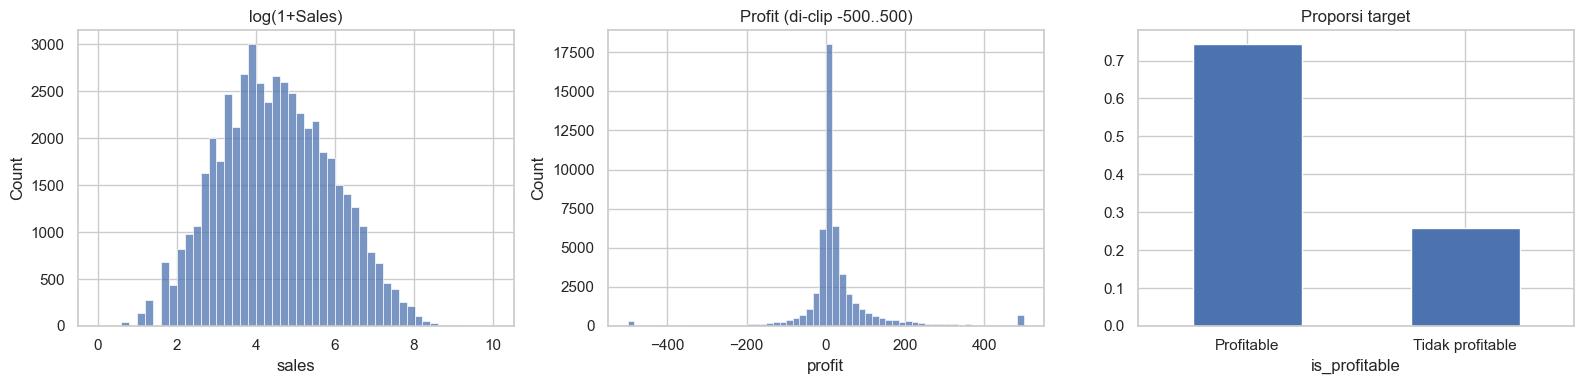

In [5]:
fig, ax = plt.subplots(1, 3, figsize=(16, 4))
sns.histplot(np.log1p(df["sales"]), bins=50, ax=ax[0]); ax[0].set_title("log(1+Sales)")
sns.histplot(df["profit"].clip(-500, 500), bins=60, ax=ax[1]); ax[1].set_title("Profit (di-clip -500..500)")
df["is_profitable"] = (df["profit"] > 0).astype(int)
df["is_profitable"].value_counts(normalize=True).rename({1: "Profitable", 0: "Tidak profitable"}).plot.bar(ax=ax[2], rot=0)
ax[2].set_title("Proporsi target")
plt.tight_layout(); plt.show()

**Penjelasan:** distribusi sales (skala log), profit, dan proporsi target klasifikasi.

**Interpretasi:** *(isi: seberapa miring distribusinya, berapa persen order item yang merugi, dan apakah target tidak seimbang sehingga perlu `class_weight`.)*

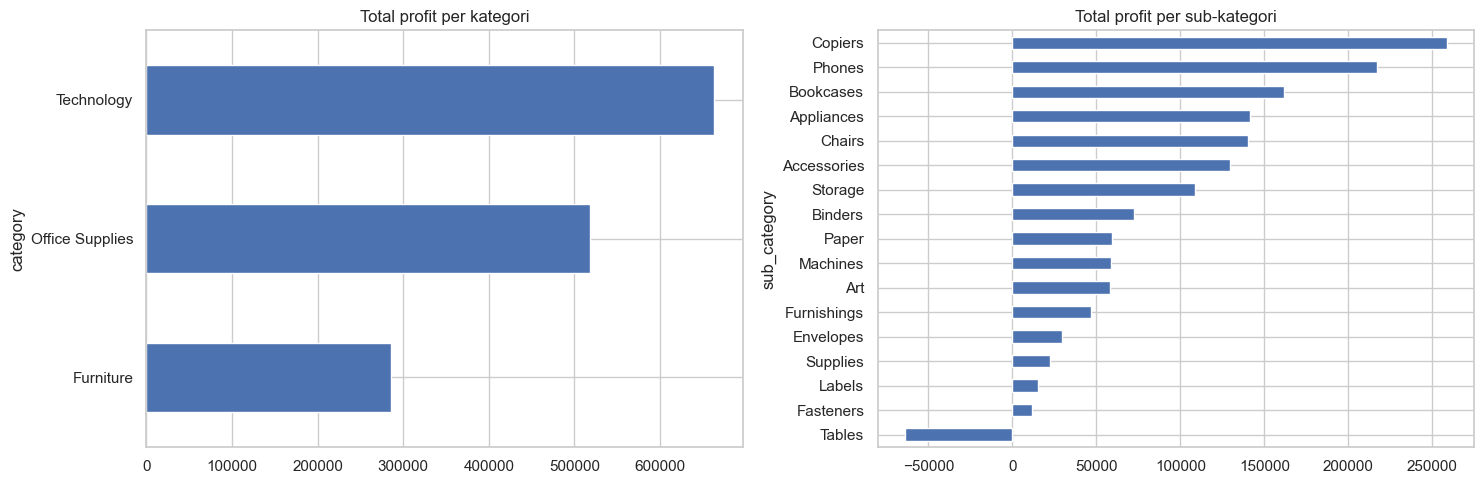

In [6]:
fig, ax = plt.subplots(1, 2, figsize=(15, 5))
df.groupby("category")["profit"].sum().sort_values().plot.barh(ax=ax[0], title="Total profit per kategori")
df.groupby("sub_category")["profit"].sum().sort_values().plot.barh(ax=ax[1], title="Total profit per sub-kategori")
plt.tight_layout(); plt.show()

**Penjelasan:** membandingkan total profit antar kategori dan sub-kategori produk.

**Interpretasi:** *(isi: kategori/sub-kategori mana yang paling menguntungkan dan mana yang merugi, dan apa implikasinya bagi pengelolaan produk.)*

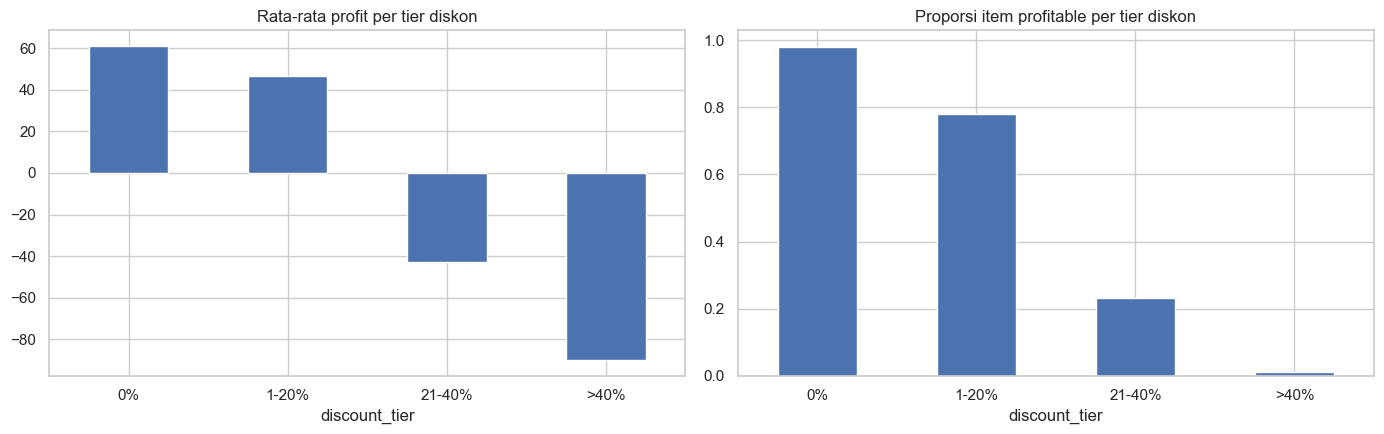

In [7]:
df["discount_tier"] = pd.cut(df["discount"], [-0.01, 0, 0.2, 0.4, 1.0], labels=["0%", "1-20%", "21-40%", ">40%"])
fig, ax = plt.subplots(1, 2, figsize=(14, 4.5))
df.groupby("discount_tier")["profit"].mean().plot.bar(ax=ax[0], rot=0, title="Rata-rata profit per tier diskon")
df.groupby("discount_tier")["is_profitable"].mean().plot.bar(ax=ax[1], rot=0, title="Proporsi item profitable per tier diskon")
plt.tight_layout(); plt.show()

**Penjelasan:** feature engineering `discount_tier` untuk melihat hubungan diskon dengan profit.

**Interpretasi:** *(isi: pada tier diskon berapa profit mulai negatif? Ini biasanya temuan bisnis paling penting.)*

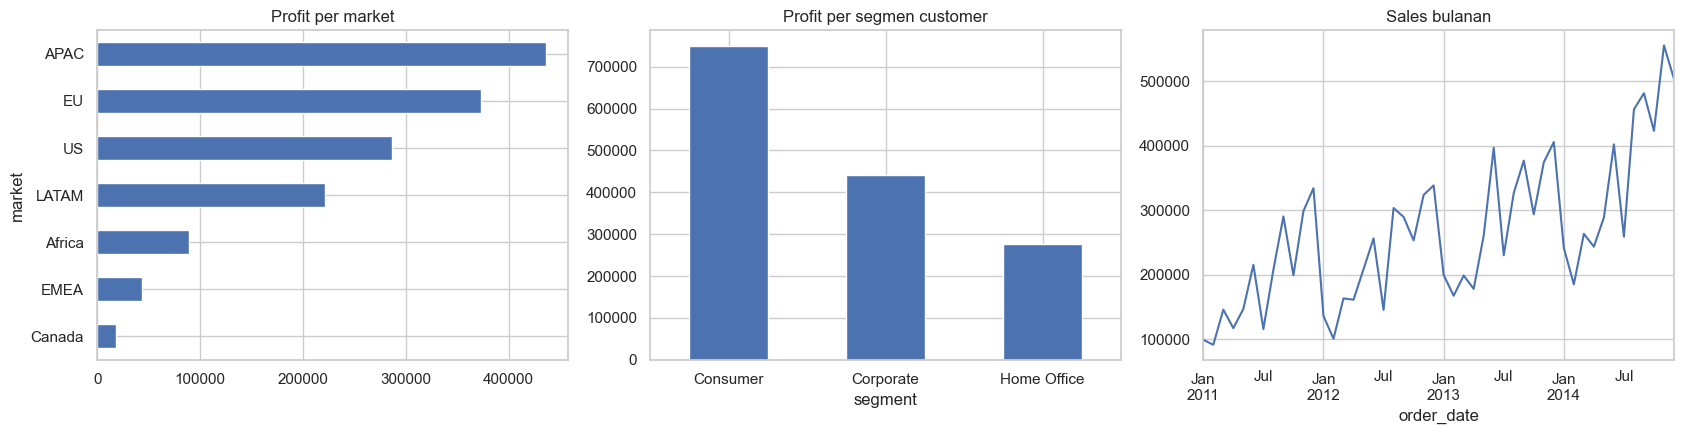

In [8]:
fig, ax = plt.subplots(1, 3, figsize=(17, 4.5))
df.groupby("market")["profit"].sum().sort_values().plot.barh(ax=ax[0], title="Profit per market")
df.groupby("segment")["profit"].sum().plot.bar(ax=ax[1], rot=0, title="Profit per segmen customer")
df.groupby(df["order_date"].dt.to_period("M"))["sales"].sum().plot(ax=ax[2], title="Sales bulanan")
plt.tight_layout(); plt.show()

**Penjelasan:** profit berdasarkan market dan segmen customer, plus tren sales bulanan.

**Interpretasi:** *(isi: market/segmen terkuat dan terlemah, serta pola musiman atau tren pertumbuhan.)*

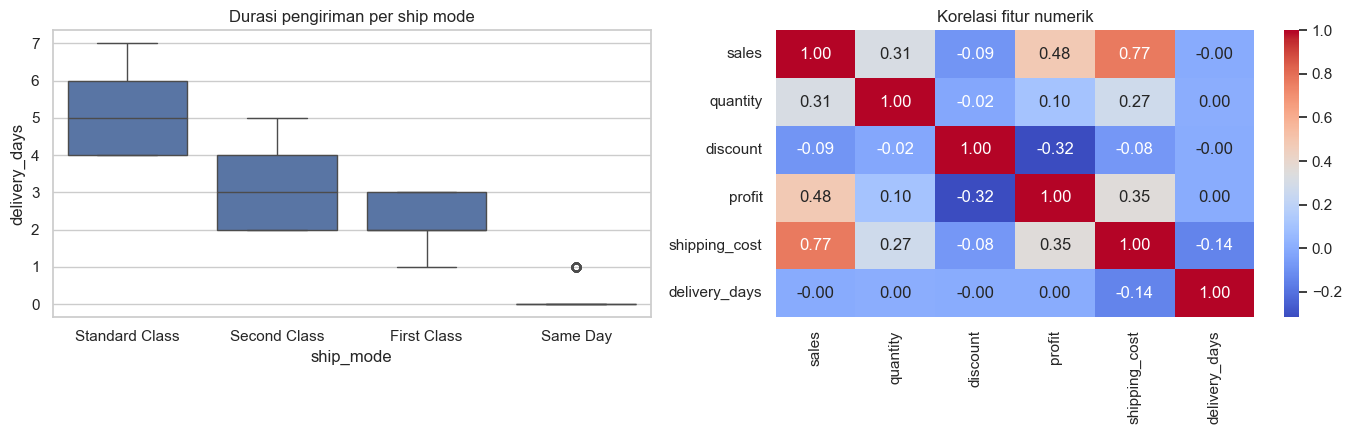

In [9]:
df["delivery_days"] = (df["ship_date"] - df["order_date"]).dt.days
fig, ax = plt.subplots(1, 2, figsize=(14, 4.5))
sns.boxplot(data=df, x="ship_mode", y="delivery_days", ax=ax[0]); ax[0].set_title("Durasi pengiriman per ship mode")
sns.heatmap(df[["sales", "quantity", "discount", "profit", "shipping_cost", "delivery_days"]].corr(), annot=True, fmt=".2f", cmap="coolwarm", ax=ax[1])
ax[1].set_title("Korelasi fitur numerik")
plt.tight_layout(); plt.show()

**Penjelasan:** durasi pengiriman per ship mode dan korelasi antar fitur numerik.

**Interpretasi:** *(isi: ship mode tercepat/terlambat, dan korelasi terkuat dengan profit; biasanya discount berkorelasi negatif.)*

## 4. Data Preprocessing & Feature Engineering
Langkah: hapus duplikat dan missing, buat `delivery_days` (ship_date − order_date), `sales_per_unit` (sales/quantity), dan target `is_profitable`. **Fitur turunan dari `profit` sengaja tidak dipakai sebagai input untuk menghindari *data leakage*.**

In [10]:
NUM = ["sales", "quantity", "discount", "shipping_cost", "delivery_days", "sales_per_unit"]
CAT = ["ship_mode", "order_priority", "segment", "category", "sub_category", "region", "market"]
df["sales_per_unit"] = df["sales"] / df["quantity"].replace(0, np.nan)
data = df.dropna(subset=NUM + CAT).drop_duplicates("row_id").copy()
print("Sebelum:", len(df), "| Sesudah:", len(data))
X, y = data[NUM + CAT], data["is_profitable"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)
print(X_train.shape, X_test.shape, y_train.mean().round(3), y_test.mean().round(3))

Sebelum: 51290 | Sesudah: 51290
(41032, 13) (10258, 13) 0.742 0.742


**Penjelasan:** membersihkan data, menyusun fitur, lalu split train/test 80:20 secara *stratified* agar proporsi kelas terjaga.

**Interpretasi:** *(isi: berapa baris yang dibuang, dan proporsi kelas pada train vs test yang harus mirip.)*

## 5. Modelling Task 1 — Classification (Profitable vs Tidak)
**Algoritma:** Random Forest. Alasan: menangkap hubungan non-linear dan interaksi (mis. diskon tinggi × kategori tertentu), tahan outlier, dan tidak butuh asumsi distribusi. Ketidakseimbangan kelas ditangani dengan `class_weight="balanced_subsample"`.

In [11]:
pre = ColumnTransformer([("num", StandardScaler(), NUM),
                         ("cat", OneHotEncoder(handle_unknown="ignore"), CAT)])
clf = Pipeline([("pre", pre), ("clf", RandomForestClassifier(
    n_estimators=300, min_samples_leaf=2, class_weight="balanced_subsample", n_jobs=-1, random_state=42))])
clf.fit(X_train, y_train)
pred, proba = clf.predict(X_test), clf.predict_proba(X_test)[:, 1]
metrics = dict(accuracy=accuracy_score(y_test, pred), precision=precision_score(y_test, pred),
               recall=recall_score(y_test, pred), f1=f1_score(y_test, pred), roc_auc=roc_auc_score(y_test, proba))
print(pd.Series(metrics).round(4))
print(classification_report(y_test, pred, target_names=["Tidak profitable", "Profitable"]))

accuracy     0.9153
precision    0.9409
recall       0.9452
f1           0.9431
roc_auc      0.9602
dtype: float64
                  precision    recall  f1-score   support

Tidak profitable       0.84      0.83      0.83      2642
      Profitable       0.94      0.95      0.94      7616

        accuracy                           0.92     10258
       macro avg       0.89      0.89      0.89     10258
    weighted avg       0.91      0.92      0.92     10258



**Penjelasan:** melatih pipeline (scaling + one-hot + Random Forest) dan menghitung Accuracy, Precision, Recall, F1, dan ROC-AUC pada data test.

**Interpretasi:** *(isi: bandingkan metrik kedua kelas. Kelas mana yang lebih sulit diprediksi? Dalam bisnis, recall pada kelas "Tidak profitable" penting karena itu pesanan rugi yang ingin dicegah. Jelaskan arti precision dan recall dalam konteks tersebut.)*

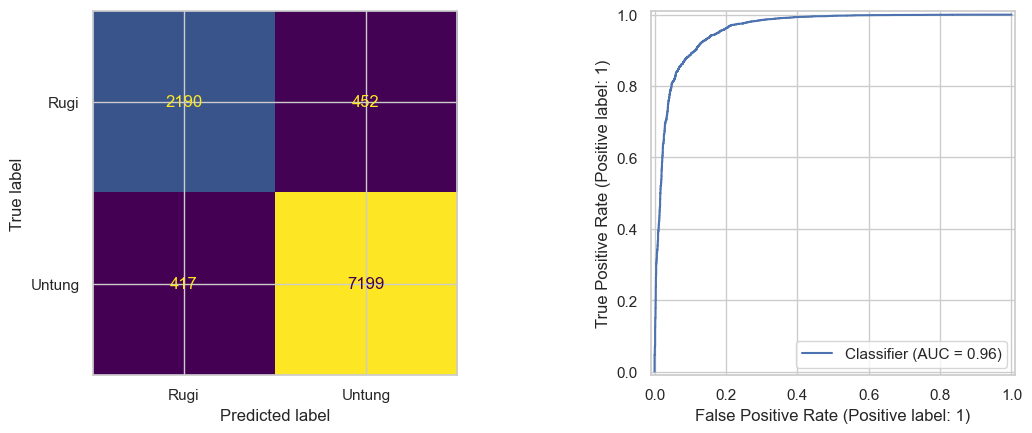

In [12]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4.5))
ConfusionMatrixDisplay(confusion_matrix(y_test, pred), display_labels=["Rugi", "Untung"]).plot(ax=ax[0], colorbar=False)
RocCurveDisplay.from_predictions(y_test, proba, ax=ax[1])
plt.tight_layout(); plt.show()

**Penjelasan:** confusion matrix dan kurva ROC.

**Interpretasi:** *(isi: jenis kesalahan yang paling sering terjadi (false positive vs false negative) dan dampak bisnisnya; seberapa jauh kurva ROC di atas garis diagonal.)*

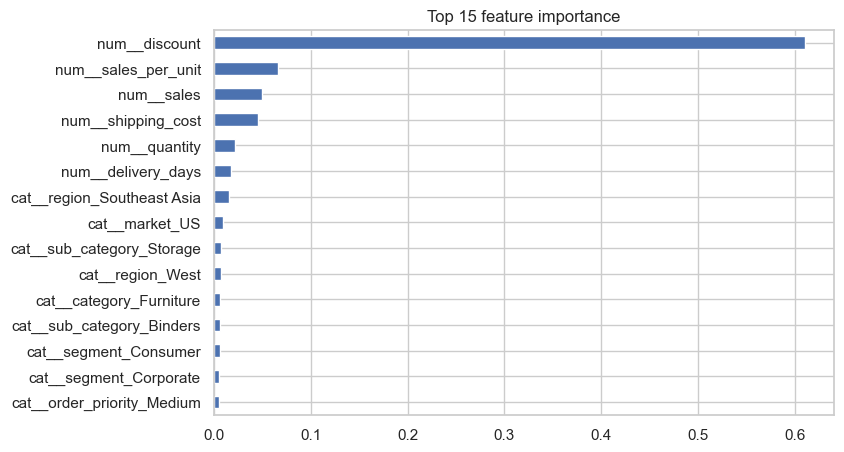

In [13]:
names = clf.named_steps["pre"].get_feature_names_out()
imp = pd.Series(clf.named_steps["clf"].feature_importances_, index=names).sort_values(ascending=False).head(15)
imp.iloc[::-1].plot.barh(figsize=(8, 5), title="Top 15 feature importance"); plt.show()

**Penjelasan:** 15 fitur yang paling berpengaruh pada prediksi.

**Interpretasi:** *(isi: fitur teratas (biasanya `discount`, `sales_per_unit`, sub-kategori) dan apa rekomendasi bisnisnya, mis. batasi diskon pada sub-kategori tertentu.)*

## 6. Modelling Task 2 — Clustering (Segmentasi Customer)
**Algoritma:** K-Means pada data level customer. Fitur: `total_sales`, `n_orders`, `avg_discount`, `profit_margin`. Fitur diskalakan dengan `PowerTransformer` karena sangat miring. Jumlah klaster dipilih dengan Elbow (inertia) dan Silhouette Score.

In [14]:
cust = data.groupby("customer_id").agg(total_sales=("sales", "sum"), total_profit=("profit", "sum"),
                                       n_orders=("order_key", "nunique"), avg_discount=("discount", "mean"))
cust["profit_margin"] = cust["total_profit"] / cust["total_sales"]
cust = cust.replace([np.inf, -np.inf], np.nan).dropna()
FEATS = ["total_sales", "n_orders", "avg_discount", "profit_margin"]
print(cust.shape); cust[FEATS].describe().round(3)

(4873, 5)


,total_sales,n_orders,avg_discount,profit_margin
count,4873.000,4873.000,4873.000,4873.000
mean,2594.481,5.285,0.142,0.071
std,2465.922,2.857,0.137,0.304
min,2.000,1.000,0.000,-2.445
25%,728.000,3.000,0.039,0.025
50%,1894.000,5.000,0.116,0.140
75%,3763.000,7.000,0.200,0.231
max,25042.000,18.000,0.700,0.508


**Penjelasan:** agregasi data per customer untuk membentuk fitur perilaku belanja.

**Interpretasi:** *(isi: jumlah customer dan rentang nilai tiap fitur.)*

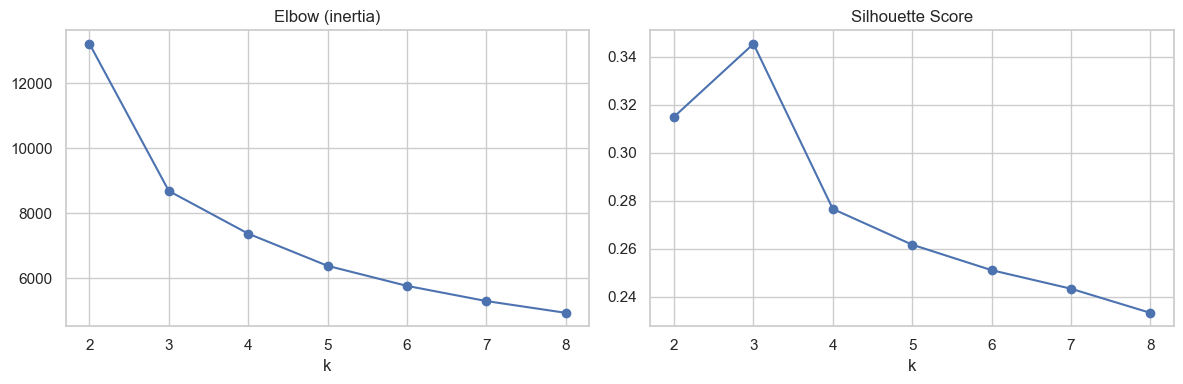

k terbaik berdasarkan silhouette: 3 | score: 0.3453


In [15]:
Xc = PowerTransformer().fit_transform(cust[FEATS])
ks, inertia, sil = range(2, 9), [], []
for k in ks:
    km = KMeans(k, n_init=10, random_state=42).fit(Xc)
    inertia.append(km.inertia_); sil.append(silhouette_score(Xc, km.labels_))
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].plot(ks, inertia, "o-"); ax[0].set(title="Elbow (inertia)", xlabel="k")
ax[1].plot(ks, sil, "o-"); ax[1].set(title="Silhouette Score", xlabel="k")
plt.tight_layout(); plt.show()
best_k = list(ks)[int(np.argmax(sil))]
print("k terbaik berdasarkan silhouette:", best_k, "| score:", round(max(sil), 4))

**Penjelasan:** mencoba k = 2..8 dan memilih k dengan Silhouette tertinggi, dibantu kurva Elbow.

**Interpretasi:** *(isi: letak "siku" pada kurva inertia, nilai silhouette dan artinya (0.25–0.5 = struktur klaster cukup/lemah-sedang), serta alasan memilih k final. Boleh memilih k lain jika lebih bermakna secara bisnis.)*

In [16]:
km_pipe = Pipeline([("scale", PowerTransformer()), ("km", KMeans(best_k, n_init=10, random_state=42))])
cust["cluster"] = km_pipe.fit_predict(cust[FEATS])
profile = cust.groupby("cluster")[FEATS].mean()
profile["n_customers"] = cust["cluster"].value_counts().sort_index()
mean = cust[FEATS].mean()
names = {}
for c, r in profile.iterrows():
    n = f"C{c}: {'High' if r.total_sales > mean.total_sales else 'Low'}-Spend, " + ("Discount-Driven" if r.avg_discount > mean.avg_discount else "Full-Price")
    if r.profit_margin < 0: n += " (Loss-Making)"
    names[int(c)] = n
cust["segment_label"] = cust["cluster"].map(names)
profile.index = profile.index.map(names)
profile.round(3)

,total_sales,n_orders,avg_discount,profit_margin,n_customers
cluster,,,,,
"C0: Low-Spend, Full-Price",996.269,2.769,0.025,0.246,1363
"C1: Low-Spend, Discount-Driven (Loss-Making)",1087.696,3.804,0.309,-0.261,1156
"C2: High-Spend, Full-Price",4259.819,7.469,0.128,0.132,2354


**Penjelasan:** melatih K-Means final, membuat profil rata-rata tiap klaster, dan memberi label deskriptif otomatis berdasarkan perbandingan terhadap rata-rata keseluruhan.

**Interpretasi:** *(isi: jelaskan arti setiap klaster dan tindakan bisnisnya, misalnya: High-Spend & Full-Price = pelanggan emas, pertahankan dengan program loyalitas; Discount-Driven & margin rendah = kurangi ketergantungan pada diskon; Loss-Making = tinjau kebijakan diskon/produk yang dibeli. Anda boleh mengganti label dengan nama yang lebih bagus.)*

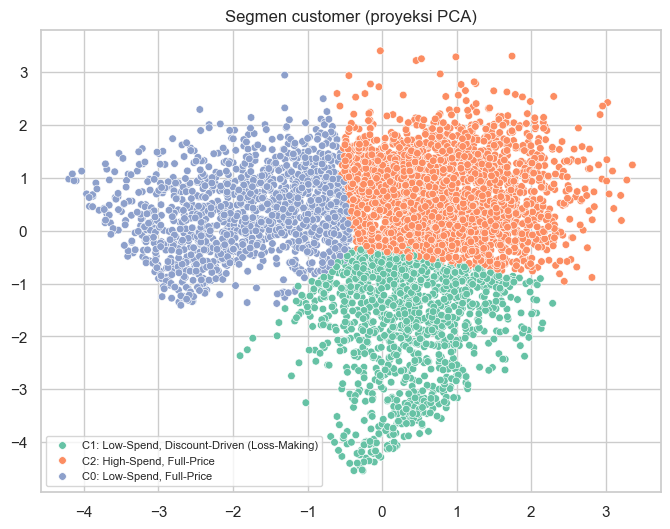

In [17]:
p = PCA(2, random_state=42).fit_transform(km_pipe[:-1].transform(cust[FEATS]))
plt.figure(figsize=(8, 6))
sns.scatterplot(x=p[:, 0], y=p[:, 1], hue=cust["segment_label"], palette="Set2", s=30)
plt.title("Segmen customer (proyeksi PCA)"); plt.legend(fontsize=8); plt.show()

**Penjelasan:** visualisasi klaster di ruang 2 dimensi lewat PCA.

**Interpretasi:** *(isi: apakah klaster terpisah jelas atau saling tumpang tindih, dan apa artinya terhadap nilai silhouette.)*

In [18]:
MODEL_DIR = Path("../model"); MODEL_DIR.mkdir(exist_ok=True)
joblib.dump(clf, MODEL_DIR / "classifier.joblib")
joblib.dump({"pipeline": km_pipe, "names": names, "features": FEATS}, MODEL_DIR / "clusterer.joblib")
meta = dict(num_features=NUM, cat_features=CAT, cluster_features=FEATS,
            categories={c: sorted(data[c].astype(str).unique().tolist()) for c in CAT},
            classification_metrics={k: round(float(v), 4) for k, v in metrics.items()},
            cluster_names=names, best_k=int(best_k))
(MODEL_DIR / "meta.json").write_text(json.dumps(meta, indent=2))
print("Model tersimpan di", MODEL_DIR.resolve())

Model tersimpan di /Users/raffyreshainapasha/Downloads/files/lnt-final-project/model


**Penjelasan:** menyimpan kedua model dan metadata (daftar fitur + pilihan kategori) ke folder `model/` agar dipakai backend tanpa training ulang.

## 7. Conclusion & Business Insights
*(Tulis dengan kata-kata tim sendiri, 3–5 poin:)*
1. **Temuan EDA utama:** (diskon vs profit, kategori/market yang merugi, dll.)
2. **Hasil klasifikasi:** (metrik utama, kelas yang sulit, fitur terpenting)
3. **Hasil klustering:** (jumlah segmen, karakter tiap segmen)
4. **Rekomendasi bisnis:** (kebijakan diskon, fokus produk/market, strategi per segmen)
5. **Keterbatasan & langkah lanjut:** (data tanpa biaya produk, tuning hyperparameter, dll.)
6. **Keterkaitan dengan tema:** bagaimana analisis data seperti ini menjembatani talenta baru dengan kebutuhan inovasi industri.